In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
X, _ = make_blobs(
    n_samples=600,
    centers=5,
    cluster_std=1.2,
    random_state=0
)

clients = pd.DataFrame(X, columns=["income", "spending_score"])

display(clients.head())

,income,spending_score
0,8.786125,-1.461927
1,-3.260832,1.465231
2,1.336883,-0.441413
3,-4.363913,2.942283
4,9.339461,-1.972397


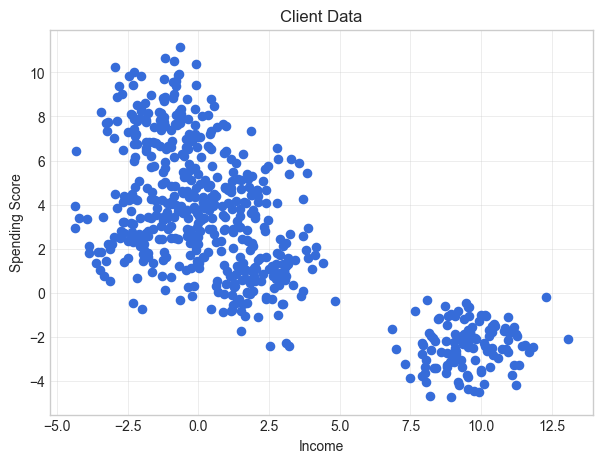

In [3]:
plt.figure(figsize=(7,5))

plt.scatter(
    clients["income"],
    clients["spending_score"],
    s=35
)

plt.title("Client Data")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [4]:
kmeans = KMeans(
    n_clusters=5,
    random_state=0
)

clients["segment"] = kmeans.fit_predict(clients[["income", "spending_score"]])

display(clients.head())

,income,spending_score,segment
0,8.786125,-1.461927,2
1,-3.260832,1.465231,3
2,1.336883,-0.441413,0
3,-4.363913,2.942283,3
4,9.339461,-1.972397,2


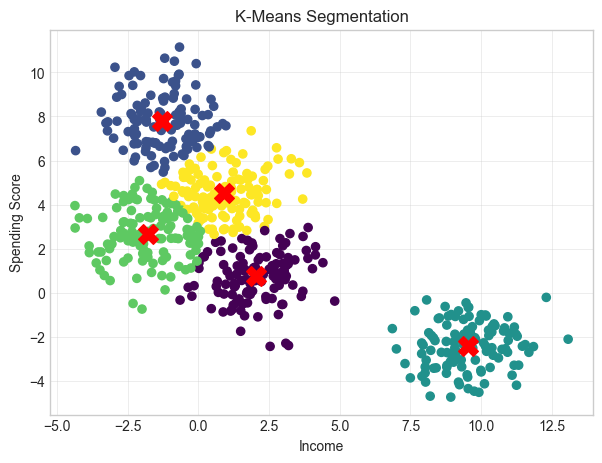

In [5]:
plt.figure(figsize=(7,5))

plt.scatter(
    clients["income"],
    clients["spending_score"],
    c=clients["segment"],
    cmap="viridis",
    s=35
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=200
)

plt.title("K-Means Segmentation")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [6]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

clients["cluster_dbscan"] = dbscan.fit_predict(clients[["income", "spending_score"]])

display(clients.head())

,income,spending_score,segment,cluster_dbscan
0,8.786125,-1.461927,2,0
1,-3.260832,1.465231,3,1
2,1.336883,-0.441413,0,1
3,-4.363913,2.942283,3,1
4,9.339461,-1.972397,2,0


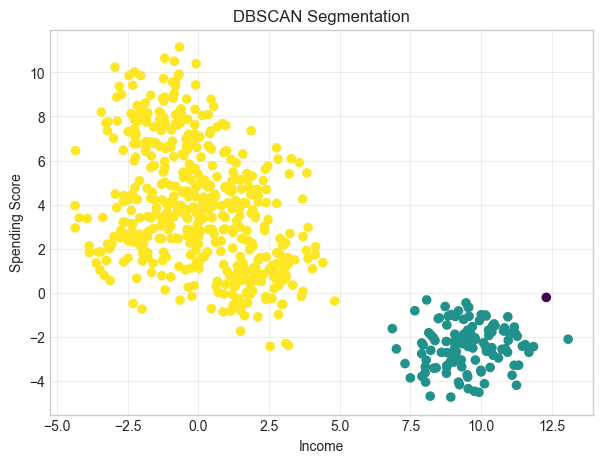

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(
    clients["income"],
    clients["spending_score"],
    c=clients["cluster_dbscan"],
    cmap="viridis",
    s=35
)

plt.title("DBSCAN Segmentation")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

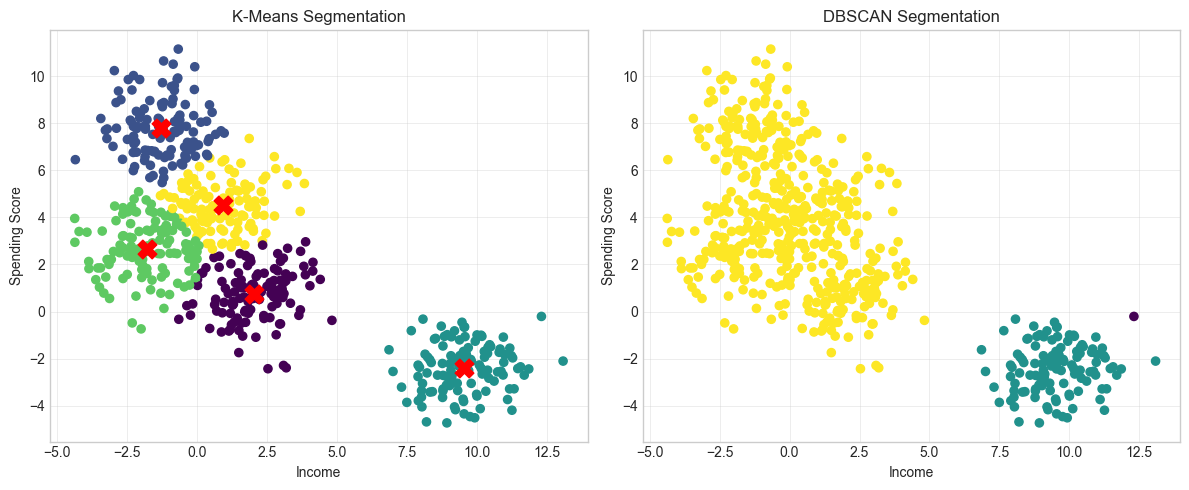

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.scatter(
    clients["income"],
    clients["spending_score"],
    c=clients["segment"],
    cmap="viridis",
    s=35
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=180
)

plt.title("K-Means Segmentation")
plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.subplot(1,2,2)

plt.scatter(
    clients["income"],
    clients["spending_score"],
    c=clients["cluster_dbscan"],
    cmap="viridis",
    s=35
)

plt.title("DBSCAN Segmentation")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.tight_layout()
plt.show()

In [9]:
noise_points = (clients["cluster_dbscan"] == -1).sum()

print(f"Кількість шумових точок: {noise_points}")

Кількість шумових точок: 1
